In [7]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from lifelines.utils import concordance_index

model = xgb.Booster()
model.load_model("model.json")

In [6]:
path = r"dataset\df_test.csv"
df_test = pd.read_csv(path)

In [22]:
first_row = df_test.iloc[[1]]  # keep as df 
 
X_first = first_row.drop(columns=["Subscription Length", "Churn"])
actual_time   = first_row["Subscription Length"].values[0]
actual_churn  = int(first_row["Churn"].values[0])

In [23]:
print(X_first.T.rename(columns={X_first.index[0]: "Value"}).to_string())
drow = xgb.DMatrix(X_first)
pred_time = model.predict(drow)[0]


                             Value
Call Failure              0.000000
Complains                 1.000000
Charge Amount             0.000000
Frequency of use         14.000000
Frequency of SMS          2.000000
Distinct Called Numbers   8.000000
Age Group                 2.000000
Tariff Plan               1.000000
Status                    1.000000
Age                      25.000000
Customer Value           71.370000
Minutes of Use           22.866667


In [24]:
print(f"Predicted churn month: {pred_time:.2f}")
print(f"Actual subscription: {actual_time} months")
print(f"Actually churned: {'Yes' if actual_churn else 'No'}")

Predicted churn month: 10.85
Actual subscription: 7 months
Actually churned: Yes


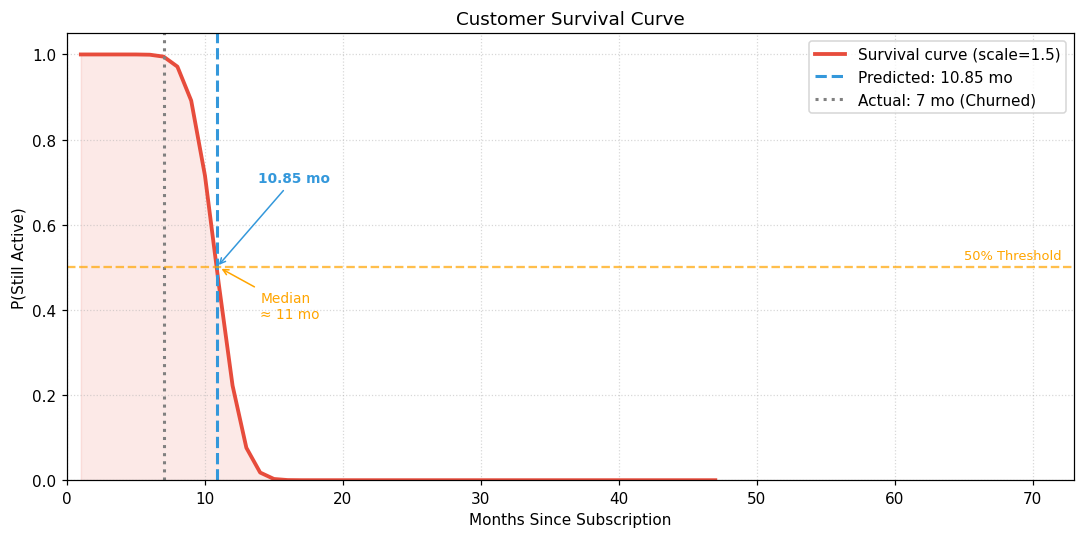

In [ ]:

times = np.arange(1, 48)  # months 1-> 47
surv_curve = norm.sf(times, loc=pred_time, scale=1.5)

# Median survival: first month where S(t) <= 0.5
median_idx = np.searchsorted(-surv_curve, -0.5)
median_time = times[median_idx] if median_idx < len(times) else None

color = "#e74c3c" if actual_churn else "#2ecc71"
status_label = "Churned" if actual_churn else "Active"

fig, ax = plt.subplots(figsize=(10, 5), dpi=110)

# Filled area under the curve
ax.fill_between(times, surv_curve, alpha=0.12, color=color)
ax.plot(times, surv_curve, color=color, linewidth=2.5,
        label=f"Survival curve (scale=1.5)")

# Predicted churn line
ax.axvline(pred_time, color="#3498db", linestyle="--", linewidth=2,
           label=f"Predicted: {pred_time:.2f} mo")
ax.annotate(
    f"{pred_time:.2f} mo",
    xy=(pred_time, norm.sf(pred_time, loc=pred_time, scale=1.5)),
    xytext=(pred_time + 3, 0.7),
    arrowprops=dict(arrowstyle="->", color="#3498db"),
    fontsize=9, color="#3498db", fontweight="bold"
)

# Actual tenure line
ax.axvline(actual_time, color="gray", linestyle=":", linewidth=2,
           label=f"Actual: {actual_time} mo ({status_label})")

# 50% threshold
ax.axhline(0.5, color="orange", linestyle="--", alpha=0.7, linewidth=1.5)
ax.text(65, 0.52, "50% Threshold", color="orange", fontsize=8.5)
if median_time:
    ax.annotate(
        f"Median\n≈ {median_time} mo",
        xy=(median_time, 0.5), xytext=(median_time + 3, 0.38),
        arrowprops=dict(arrowstyle="->", color="orange"),
        fontsize=9, color="orange"
    )

ax.set_title("Customer Survival Curve")
ax.set_xlabel("Months Since Subscription")
ax.set_ylabel("P(Still Active)")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 73)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()